In [2]:
dataset_path = "./images_dataSAT"

import os
print(os.listdir(dataset_path))

['class_1_agri', 'class_0_non_agri', 'Module1_Data_Loading.ipynb']


In [3]:
#Task 1 — Recursively collect image filenames

import os

image_filenames = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_filenames.append(os.path.join(root, file))

print("Total image files:", len(image_filenames))
print("First 5 files:", image_filenames[:5])

Total image files: 6000
First 5 files: ['./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_5974.jpg', './images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_23339.jpg', './images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_13279.jpg', './images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_0840.jpg', './images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_15146.jpg']


In [4]:
#Task 2 — Create the validation generator

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

validation_datagen = ImageDataGenerator(rescale=1.0 / 255)

validation_generator = validation_datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", validation_generator.class_indices)
print("Total validation images:", validation_generator.samples)

Found 6000 images belonging to 2 classes.
Class indices: {'class_0_non_agri': 0, 'class_1_agri': 1}
Total validation images: 6000


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Create CNN model
test_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(2, activation="softmax")
])

test_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

test_model.summary()

/Users/hussainbohra/jupyter313/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 415,954 (1.59 MB)

 Trainable params: 415,954 (1.59 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
#Task 3 — Count the CNN model layers
print("Total layers in CNN model:", len(test_model.layers))

Total layers in CNN model: 16


In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    filepath="best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

print("Checkpoint callback created successfully!")

Checkpoint callback created successfully!


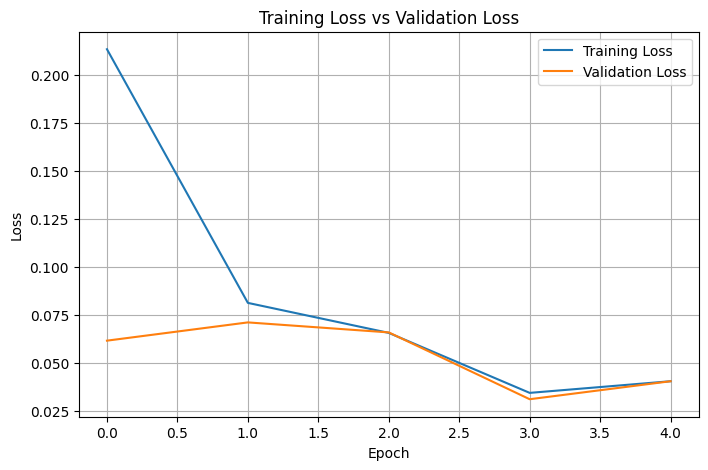

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    seed=42
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    seed=42
)

history = test_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    callbacks=[checkpoint_callback]
)

Found 4800 images belonging to 2 classes.
Found 1200 images belonging to 2 classes.
Epoch 1/5
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9001 - loss: 0.2163
Epoch 1: val_accuracy improved from None to 0.98500, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9015 - loss: 0.2135 - val_accuracy: 0.9850 - val_loss: 0.0616
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9733 - loss: 0.0813
Epoch 2: val_accuracy did not improve from 0.98500
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9733 - loss: 0.0813 - val_accuracy: 0.9833 - val_loss: 0.0711
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9752 - loss: 0.0657
Epoch 3: val_accuracy did not improve from 0.98500
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9752 - loss: 0.0657 - val_accuracy: 0.9675 - val_loss: 0.0659
Epoch 4/5
148/150 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 